In [85]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [86]:

# data = pd.read_csv(r'../dataset/full.csv')
data = pd.read_csv(r'../dataset/full_v2.csv')
# data = pd.read_csv(r'../dataset/data_subject1.csv')

data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [87]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 542 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(540), int64(1), str(1)
memory usage: 42.6 MB


In [88]:
min_max = data.agg(['min', 'max'])
# min_max.to_csv(r'../dataset/min_max.csv', index=False)

In [89]:
count_values = pd.DataFrame(columns=['Subject', 'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING'])

for i in range(30):
    df = pd.read_csv(r'../dataset/data_subject' + str(i+1) + '.csv')
    df_column_labels = df.columns.tolist()
    # Only include 'activity'
    df = df.drop(columns=df_column_labels[:-1])
    # Count occurences of categorical data in activity
    counts = df['Activity'].value_counts()
    count_values.loc[i] = [i + 1, counts.get('WALKING', 0), counts.get('WALKING_UPSTAIRS', 0), counts.get('WALKING_DOWNSTAIRS', 0), counts.get('SITTING', 0), counts.get('STANDING', 0), counts.get('LAYING', 0)]
    count_values.loc[i] = [i + 1, counts.get('WALKING', 0), counts.get('WALKING_UPSTAIRS', 0), counts.get('WALKING_DOWNSTAIRS', 0), counts.get('SITTING', 0), counts.get('STANDING', 0), counts.get('LAYING', 0)]
count_values.head()
# count_values.to_csv(r'../dataset/activity_distribution.csv', index=False)

,Subject,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
0,1,95,53,49,47,53,50
1,2,59,48,47,46,54,48
2,3,58,59,49,52,61,62
3,4,60,52,45,50,56,54
4,5,56,47,47,44,56,52


In [90]:
# Calculate average distribution of activities across all subjects
average_distribution = count_values[['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']].mean()
average_distribution_df = pd.DataFrame(average_distribution).reset_index()
average_distribution_df.columns = ['Activity', 'Average Count']
# average_distribution_df.to_csv(r'../dataset/average_activity_distribution.csv', index=False)

<Axes: xlabel='Subject'>

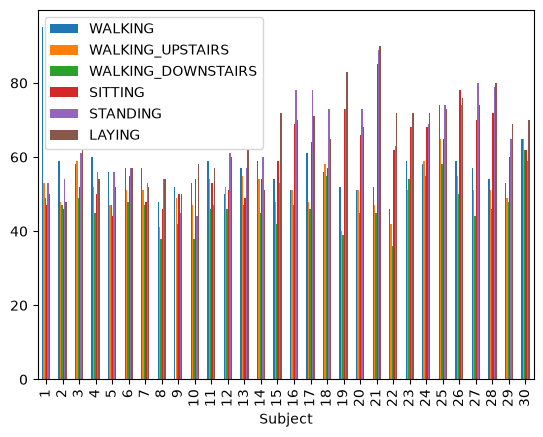

In [91]:
# Plot count_values
count_values.plot(x='Subject', y=['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING'], kind='bar')

<Axes: xlabel='Subject', ylabel='Sample count'>

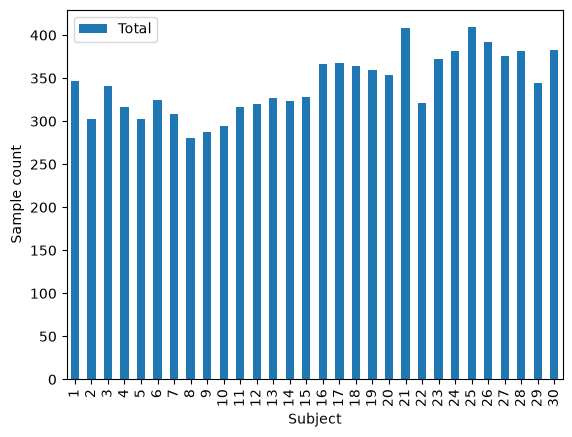

In [92]:
# Add a column that adds up all activity occurences for each subject
count_values['Total'] = count_values[['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']].sum(axis=1)
count_values.head()
count_values.plot(x='Subject', y='Total', ylabel = "Sample count", kind='bar')

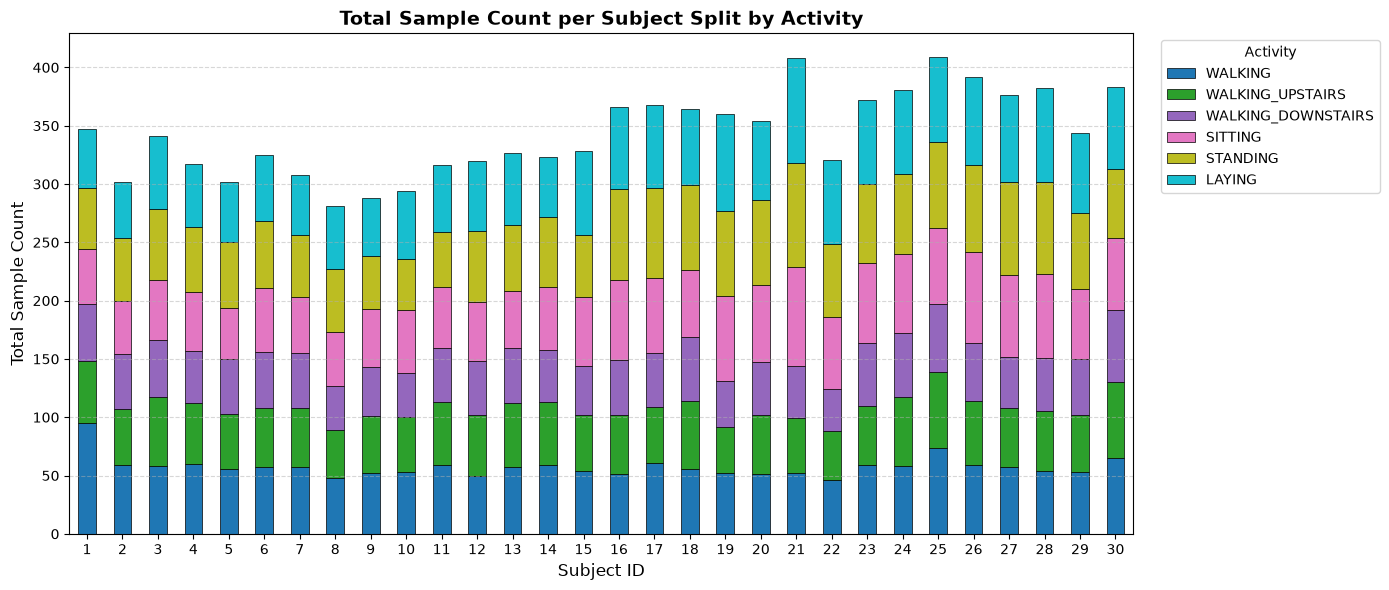

In [93]:
# 2. Set 'Subject' as index so it appears on the X-axis
df_plot = count_values.set_index('Subject')
df_plot = df_plot.drop(columns=['Total'])  # Drop the 'Total' column for the stacked bar plot

# 3. Create stacked bar plot
ax = df_plot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 6), 
    colormap='tab10', 
    edgecolor='black',
    linewidth=0.5
)

# 4. Customize plot labels and formatting
plt.title('Total Sample Count per Subject Split by Activity', fontsize=14, fontweight='bold')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Total Sample Count', fontsize=12)
plt.xticks(rotation=0)  # Keep subject numbers horizontal
plt.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')  # Place legend outside
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

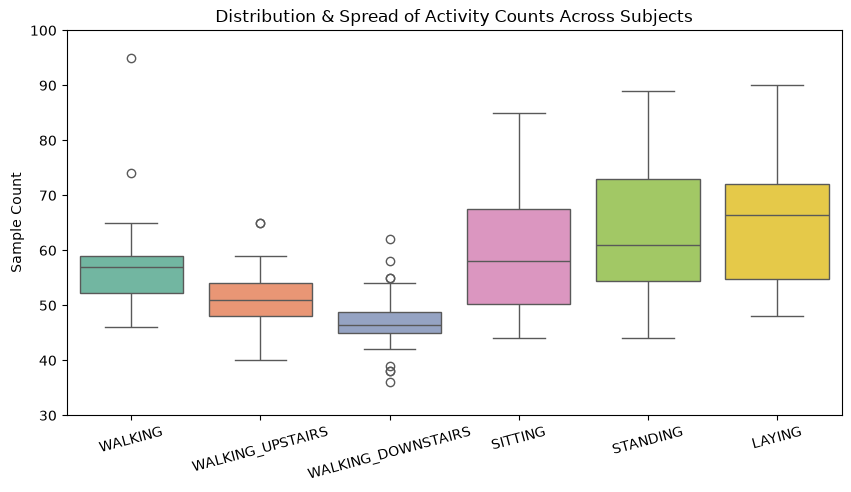

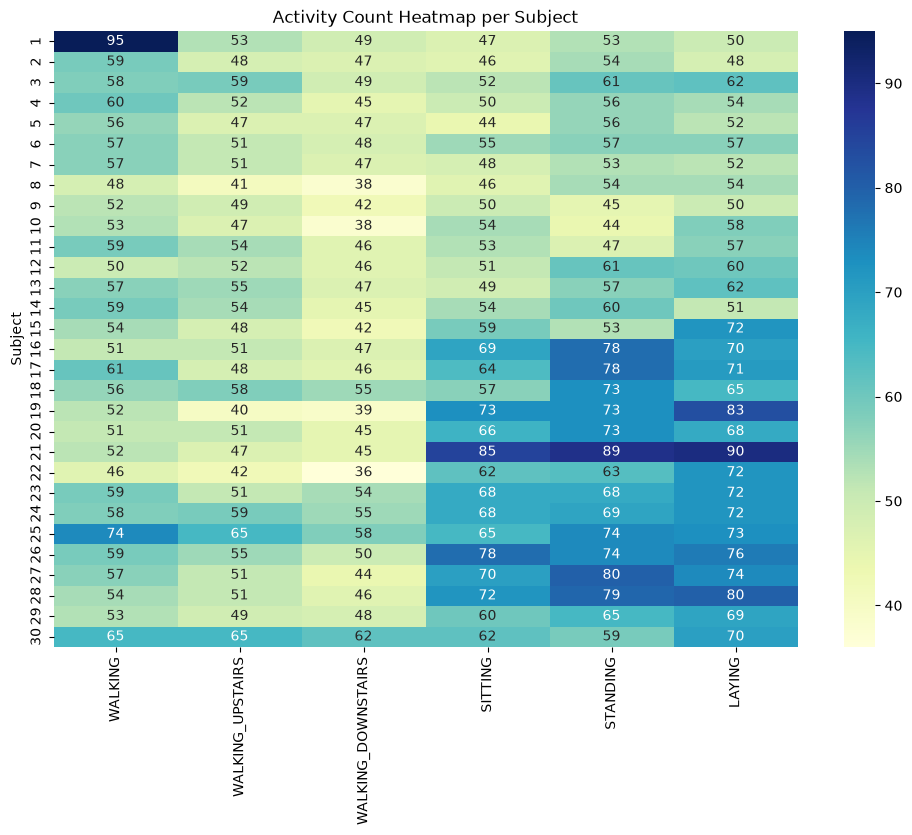

In [94]:
activity_cols = [c for c in count_values.columns if c != "Subject" and c != "Total"]
count_values = count_values.drop(columns=['Total'])

# Boxplot: See variance and range across activities
plt.figure(figsize=(10, 5))
sns.boxplot(data=count_values[activity_cols], palette="Set2")
plt.title("Distribution & Spread of Activity Counts Across Subjects")
plt.ylabel("Sample Count")
plt.xticks(rotation=15)
plt.ylim(30, 100)
plt.show()

# Heatmap: Spot patterns/outliers per subject
plt.figure(figsize=(12, 8))
sns.heatmap(
    count_values.set_index("Subject")[activity_cols],
    annot=True,
    fmt="d",
    cmap="YlGnBu",
)
plt.title("Activity Count Heatmap per Subject")
plt.show()

In [95]:
column_list = data.columns.tolist()
for i in column_list:
    print(i)

tBodyAcc-mean()-X
tBodyAcc-mean()-Y
tBodyAcc-mean()-Z
tBodyAcc-std()-X
tBodyAcc-std()-Y
tBodyAcc-std()-Z
tBodyAcc-mad()-X
tBodyAcc-mad()-Y
tBodyAcc-mad()-Z
tBodyAcc-max()-X
tBodyAcc-max()-Y
tBodyAcc-max()-Z
tBodyAcc-min()-X
tBodyAcc-min()-Y
tBodyAcc-min()-Z
tBodyAcc-sma()
tBodyAcc-energy()-X
tBodyAcc-energy()-Y
tBodyAcc-energy()-Z
tBodyAcc-iqr()-X
tBodyAcc-iqr()-Y
tBodyAcc-iqr()-Z
tBodyAcc-entropy()-X
tBodyAcc-entropy()-Y
tBodyAcc-entropy()-Z
tBodyAcc-arCoeff()-X,1
tBodyAcc-arCoeff()-X,2
tBodyAcc-arCoeff()-X,3
tBodyAcc-arCoeff()-X,4
tBodyAcc-arCoeff()-Y,1
tBodyAcc-arCoeff()-Y,2
tBodyAcc-arCoeff()-Y,3
tBodyAcc-arCoeff()-Y,4
tBodyAcc-arCoeff()-Z,1
tBodyAcc-arCoeff()-Z,2
tBodyAcc-arCoeff()-Z,3
tBodyAcc-arCoeff()-Z,4
tBodyAcc-correlation()-X,Y
tBodyAcc-correlation()-X,Z
tBodyAcc-correlation()-Y,Z
tGravityAcc-mean()-X
tGravityAcc-mean()-Y
tGravityAcc-mean()-Z
tGravityAcc-std()-X
tGravityAcc-std()-Y
tGravityAcc-std()-Z
tGravityAcc-mad()-X
tGravityAcc-mad()-Y
tGravityAcc-mad()-Z
tGravityAcc-m

In [96]:
data.sample(8)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
559,0.274645,-0.015177,-0.104660,-0.994442,-0.985121,-0.981705,-0.995842,-0.987179,-0.979499,-0.939174,...,-0.344783,-0.021427,0.261766,0.059198,0.076673,-0.584410,-0.120854,-0.173752,3,SITTING
3741,0.346907,-0.003289,-0.123129,-0.075290,0.053926,-0.341924,-0.178322,0.107413,-0.354433,0.384563,...,-0.782397,-0.532226,-0.411796,-0.669444,0.739108,-0.769353,0.255067,0.046557,19,WALKING
4569,0.288239,-0.018301,-0.115272,-0.980609,-0.921857,-0.943402,-0.981479,-0.917572,-0.941591,-0.922185,...,-0.702598,-0.203519,-0.130400,-0.080942,0.073903,-0.553364,-0.085958,-0.237065,22,SITTING
3689,0.274669,-0.018295,-0.106510,-0.990648,-0.970206,-0.978206,-0.990074,-0.971353,-0.978156,-0.938192,...,-0.704888,0.103008,0.425976,-0.161965,-0.346280,0.591927,-0.576134,-0.428018,19,LAYING
8648,0.199761,-0.034135,-0.138411,-0.294426,-0.280983,-0.335962,-0.333005,-0.360597,-0.354816,-0.096881,...,-0.282506,0.495487,0.029015,0.367045,-0.448198,-0.874567,0.179253,0.050056,12,WALKING
5191,0.278897,-0.030306,-0.096043,-0.555352,-0.104055,-0.438064,-0.572530,-0.112149,-0.429688,-0.479744,...,0.200267,-0.155279,-0.137981,0.929236,-0.583898,-0.703989,0.159112,-0.185944,25,WALKING
7691,0.272555,-0.014618,-0.100014,-0.996326,-0.989437,-0.970511,-0.996931,-0.988957,-0.973693,-0.939010,...,-0.896169,0.013161,-0.037201,0.204175,-0.312510,-0.622178,-0.128289,-0.119220,4,SITTING
9306,0.198414,-0.003012,-0.114704,-0.329033,-0.154607,-0.583157,-0.369972,-0.148297,-0.599818,-0.149095,...,-0.786186,0.883983,-0.453526,-0.533504,-0.079833,-0.759698,0.254593,-0.039384,18,WALKING


In [97]:
pca_data = data.drop(columns=["subject", "Activity"])
pca = PCA()
X_pca = pca.fit_transform(pca_data)

X_pca = pd.DataFrame(X_pca)

X_pca = X_pca.join(data[['Activity', 'subject']])

X_pca.to_csv(rf'../dataset/pca_transformed_data_{dt.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv', index=False)

In [98]:
pca_data = data.drop(columns=['Activity', 'subject'])

pca = PCA().fit(pca_data)

# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the threshold index (e.g., 95% variance)
target_variance = 0.95
n_components_needed = np.argmax(cumulative_variance >= target_variance) + 1

print(f"Components needed for {target_variance * 100}% variance: {n_components_needed}")

# Refit or transform using the elected number of components
pca_final = PCA(n_components=n_components_needed)
X_pca = pca_final.fit_transform(pca_data)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components_needed)])
X_pca_df = X_pca_df.join(data[['Activity', 'subject']])
X_pca_df.to_csv(rf'../dataset/pca_transformed_data_{target_variance}_target_variance.csv', index=False)

Components needed for 95.0% variance: 71


In [28]:
# Visualize PCA results
pca_plot = pca_final.iloc[:, :2].copy()
pca_plot.columns = ['PC1', 'PC2']
pca_plot['Activity'] = data['Activity'].to_numpy()

sns.scatterplot(
    data=pca_plot,
    x='PC1',
    y='PC2',
    hue='Activity',
    palette='tab10',
    alpha=0.7,
    s=45,
)

plt.title('PCA: first two principal components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

AttributeError: 'PCA' object has no attribute 'iloc'